# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from scipy.stats import randint, uniform
from sklearn.model_selection import  PredefinedSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet
import os
import sys
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.gapfilling_utils import (
    setup_log_transform,
    undersample_target,
    infer_cv_block_size_from_gaps,
    create_block_splits,
    plot_cv_splits
)

# CONFIGURATION

In [2]:
START_DATE, END_DATE = '2023-10-18', '2024-08-21'
TARGET_FLUX = 'NEE'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
N_FOLDS = 10
PARCEL_CERTAIN = False # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_ID = True
ADD_TRT = True

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"81.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()
print(f"\nUsing data from {START_DATE} to {END_DATE}")
TARGET = f"{TARGET_FLUX}_L3.3_CUT_50_QCF0"
print(f"\nTarget column: {TARGET}")

data_main

Loaded .parquet file 81.1.1_GapFillingDataset.parquet (0.423 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 

Using data from 2023-10-18 to 2024-08-21

Target column: NEE_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_16_QCF,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_84_QCF,NEE_L3.3_CUT_16_QCF0,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FC_RANDUNC_HF,SW_IN_POT,prec,ta,ppfd,sw_in,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-18 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,0.0,6.900000,0.0,0.0,...,0.371742,-0.201140,-0.336475,0.617176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,817
2023-10-18 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,0.0,6.866667,0.0,0.0,...,0.473099,-0.073307,-0.363120,0.571588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,818
2023-10-18 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,0.0,7.033333,0.0,0.0,...,0.448120,-0.095540,-0.332609,0.480687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,819
2023-10-18 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,0.0,7.033333,0.0,0.0,...,0.334039,0.217531,-0.234399,0.239516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,820
2023-10-18 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,0.0,7.133333,0.0,0.0,...,0.299166,0.445909,-0.170026,0.292236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,0.445311,0.0,0.0,13.353333,0.0,0.0,...,-1.707135,0.024579,-0.259299,-0.314632,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.0,0.0,15644
2024-08-21 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,0.253402,0.0,0.0,12.743333,0.0,0.0,...,-1.744187,0.026603,-0.248552,-0.346094,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.0,0.0,15645
2024-08-21 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,1.454100,0.0,0.0,12.346667,0.0,0.0,...,-1.720830,0.028865,-0.235925,-0.360680,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.0,0.0,15646


# CLEAN DATA

In [4]:
# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove data with mixed attribution if PARCEL_CERTAIN==True
if PARCEL_CERTAIN:
    before = len(data)
    data = data.loc[data["parcel_certainty"].eq("certain")].copy()
    print(f"Filtered parcel_certainty=='certain': {len(data)}/{before} rows kept")
else:
    print("Using all data regardless of parcel_certainty (mixed contribution allowed)")

data

Using all data regardless of parcel_certainty (mixed contribution allowed)


,NEE_L3.3_CUT_16_QCF,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_84_QCF,NEE_L3.3_CUT_16_QCF0,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FC_RANDUNC_HF,SW_IN_POT,prec,ta,ppfd,sw_in,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-22 11:15:00,0.870527,0.870527,0.870527,0.870527,0.870527,0.870527,A,certain,0.0,0.181704,508.623,0.238,3.166667,100.485834,49.333333,...,1.199013,0.861383,1.659645,2.910261,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.455241,5.052711,2519
2023-11-22 11:45:00,0.844507,0.844507,0.844507,0.844507,0.844507,0.844507,A,certain,0.0,0.059309,531.452,0.000,3.043333,78.235791,38.666667,...,1.485885,-0.853927,-1.348990,1.416971,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.455389,5.052819,2520
2023-11-22 12:15:00,0.629330,0.629330,0.629330,0.629330,0.629330,0.629330,A,certain,0.0,0.066009,539.106,0.000,3.056667,82.407674,40.666667,...,1.168242,-1.600306,-1.980507,0.359746,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.455538,5.052927,2521
2023-11-22 12:45:00,0.602554,0.602554,0.602554,0.602554,0.602554,0.602554,A,certain,0.0,0.051177,531.452,0.000,3.000000,98.399892,48.333333,...,1.077855,-1.631950,-1.463329,-0.060023,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.455686,5.053035,2522
2023-11-22 13:15:00,0.477717,0.477717,0.477717,0.477717,0.477717,0.477717,A,certain,0.0,0.112857,508.623,0.000,2.946667,117.173366,57.333333,...,1.167029,-3.529501,-1.774765,-0.246205,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.455835,5.053143,2523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 13:45:00,-0.758393,-0.758393,-0.758393,-0.758393,-0.758393,-0.758393,B,certain,1.0,0.284435,1025.990,0.000,20.496667,1373.467598,680.736891,...,-1.612833,-0.233102,-0.273040,-0.280486,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.000000,0.000000,15628
2024-08-21 14:45:00,-0.768915,-0.768915,-0.768915,-0.768915,-0.768915,-0.768915,B,uncertain,1.0,0.237696,910.255,0.000,21.396667,1471.697962,720.283411,...,-1.662231,-0.259219,-0.330612,-0.316313,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.000000,0.000000,15630
2024-08-21 15:15:00,-0.536841,-0.536841,-0.536841,-0.536841,-0.536841,-0.536841,B,certain,1.0,0.264557,833.784,0.000,21.536667,1360.391115,676.136928,...,-1.664014,-0.261534,-0.312375,-0.314981,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.000000,0.000000,15631


# SELECT FEATURES

In [5]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
# 'timesince_soil_preparation',
# 'n_decay_timed',
# 'timesince_fert',
# 'wfps_0.05_gfXG_lag9h',
# 'wfps_0.05_gfXG_roll3hmean',
# 'ts_0.3_gfXG_lag6h_roll9hmean',
# 'GPP_U50_f_reddyproc_roll3hsum'
# ]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')

# Drop NAs and keep only selected features
train_mask = data[TARGET].notna() & data[selected_features].notna().all(axis=1)
df_train = data.loc[train_mask, selected_features + [TARGET]].copy()
print(f"\nTraining rows (complete-case): {len(df_train)}/{len(data)}")

X = df_train[selected_features]
y = df_train[TARGET].astype(float)

df_train


The treatment variable (trt) is included in the feature set

Training rows (complete-case): 6569/6569


,SW_IN_POT,ppfd,sw_in,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,crop,timesince_soil_preparation,timesince_harvest,ts_0.05_gfXG_lag6h,ts_0.05_gfXG_lag9h,ts_0.15_gfXG_lag3h,ts_0.15_gfXG_lag6h,ts_0.3_gfXG_lag6h,...,wfps_0.3_gfXG_lag6h_roll6hmean,wfps_0.3_gfXG_lag9h_roll6hmean,ts_0.05_gfXG_diff12h,ts_0.15_gfXG_diff6h,wfps_0.05_gfXG_diff24h,n_decay_linear,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,LAI,can_height,id,trt,NEE_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-22 11:15:00,508.623,100.485834,49.333333,7.766860,50.003806,56.279186,46.719290,1.0,35.0,60.0,4.294024,4.616219,6.042967,5.456263,7.881455,...,46.015745,45.170616,-2.164167,1.337738,2.928839,0.0,0.0,0.0,0.0,30.0,0.455241,5.052711,2519,0.0,0.870527
2023-11-22 11:45:00,531.452,78.235791,38.666667,7.739503,49.749778,56.502881,45.122243,1.0,35.0,60.0,4.319656,4.310134,5.968808,5.422790,7.890896,...,45.974489,45.299568,-1.543439,1.354507,2.715081,0.0,0.0,0.0,0.0,30.0,0.455389,5.052819,2520,0.0,0.844507
2023-11-22 12:15:00,539.106,82.407674,40.666667,7.751822,50.231189,56.340153,44.602581,1.0,35.0,60.0,4.333626,4.307336,5.713143,5.444772,7.934393,...,45.942806,45.423358,-1.026032,1.424386,3.131318,0.0,0.0,0.0,0.0,30.0,0.455538,5.052927,2521,0.0,0.629330
2023-11-22 12:45:00,531.452,98.399892,48.333333,7.714983,49.543728,56.270616,44.413254,1.0,36.0,60.0,4.278334,4.310931,5.683460,5.453608,7.949709,...,45.956858,45.618180,-1.164940,1.402835,2.835273,0.0,0.0,0.0,0.0,30.0,0.455686,5.053035,2522,0.0,0.602554
2023-11-22 13:15:00,508.623,117.173366,57.333333,7.638218,49.836477,56.365712,44.046013,1.0,36.0,60.0,4.197187,4.332117,5.562917,5.430867,7.914603,...,46.103086,45.832991,-0.946833,1.406002,2.859792,0.0,0.0,0.0,0.0,30.0,0.455835,5.053143,2523,0.0,0.477717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 13:45:00,1025.990,1373.467598,680.736891,19.909629,31.188045,45.364764,42.633439,2.0,17.0,28.0,19.089631,19.252592,20.199259,20.300000,20.185557,...,42.864564,42.885865,1.827036,0.229630,-4.477180,0.0,0.0,0.0,0.0,30.0,0.000000,0.000000,15628,1.0,-0.758393
2024-08-21 14:45:00,910.255,1471.697962,720.283411,19.930368,30.709276,45.232277,42.566767,2.0,17.0,28.0,19.208888,19.100741,20.207037,20.200000,20.103333,...,42.853109,42.878538,2.964445,0.596296,-4.710460,0.0,0.0,0.0,0.0,30.0,0.000000,0.000000,15630,1.0,-0.768915
2024-08-21 15:15:00,833.784,1360.391115,676.136928,19.990000,30.527820,45.214621,42.548249,2.0,17.0,28.0,19.205185,19.051112,20.299259,20.200000,20.076668,...,42.848872,42.875820,3.562222,0.730000,-4.738651,0.0,0.0,0.0,0.0,30.0,0.000000,0.000000,15631,1.0,-0.536841


# IMBALANCE HANDLING

## UNDER SAMPLING

In [6]:
if UNDERSAMPLE:
    df_train2, cutoff_value = undersample_target(
        df_train, TARGET,
        quantile_cutoff=0.8,
        fraction=0.5,
        random_state=42,
        verbose=True,
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
else:
    print("Undersampling not applied.")

Undersampling not applied.


## LOG TRANSFORMATION

In [7]:
if LOG_TRANSFORM:
    log_fn, inv_fn, min_value, df_train2 = setup_log_transform(
        df_train, TARGET, apply=True, plot=True, bins=20
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
    print(f"Applied log1p transform (shift={min_value if min_value < 0 else 0.0:.4g}).")
else:
    inv_fn = None
    print("Log transform not applied.")

Log transform not applied.


# CROSS-VAL SPLITS


Using block size of 7 time steps for CV splits.

Requested split=0.10; n_folds=10; achieved test fractions ~ 0.099–0.100


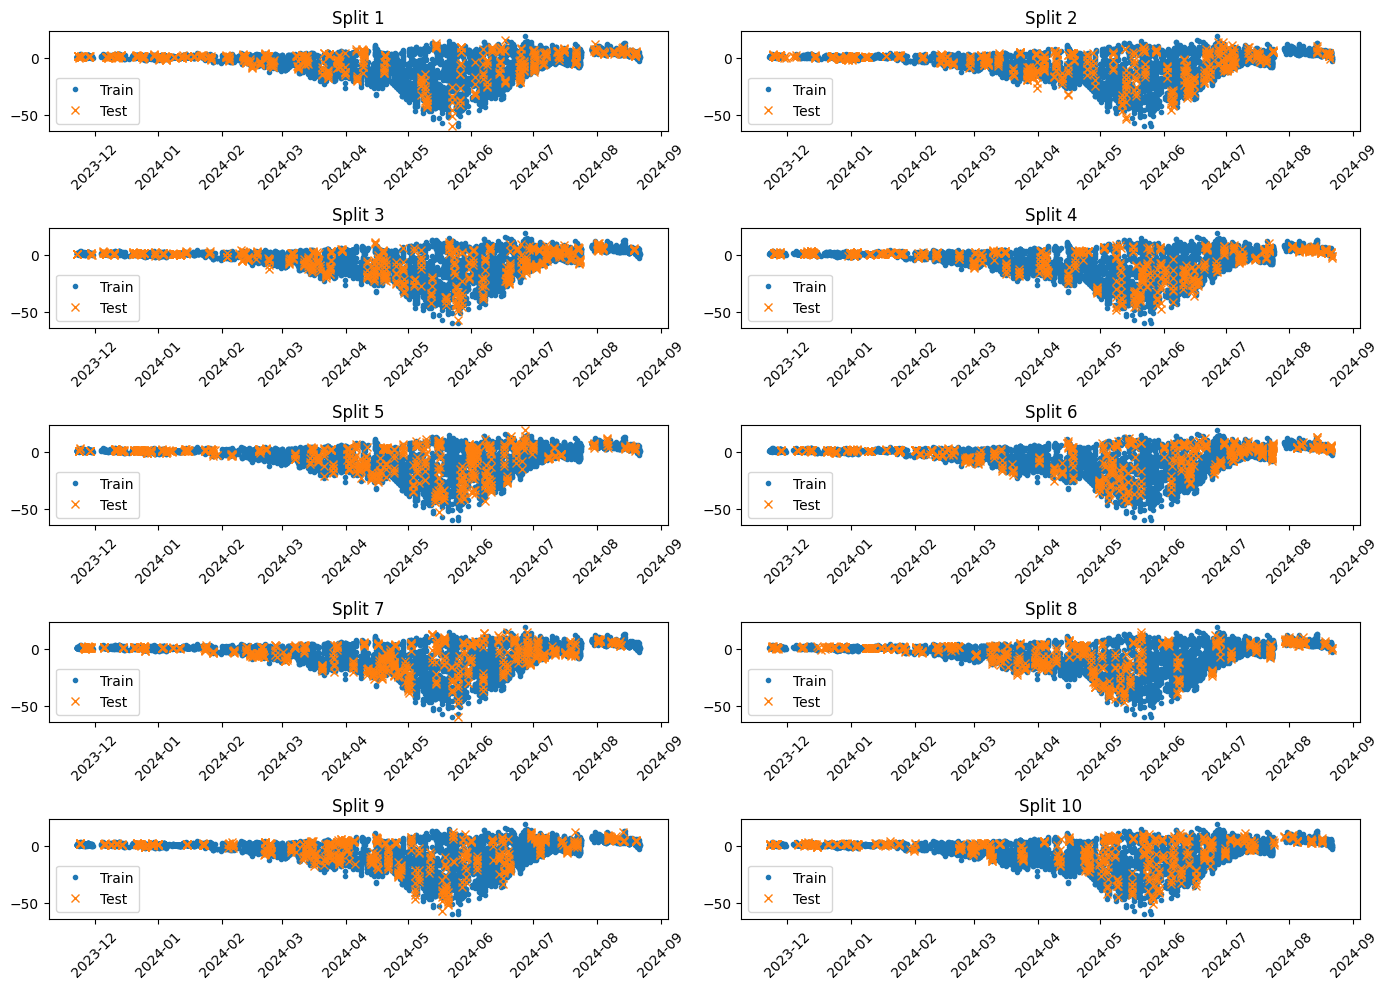

In [8]:
# Time-block cross-validation splits
# Block size is inferred from gaps in the target variable
block_size = infer_cv_block_size_from_gaps(data_main[TARGET], quantile=0.9, fallback=6)
print(f"\nUsing block size of {block_size} time steps for CV splits.\n")
split_frac = 1.0 / float(N_FOLDS)
splits = create_block_splits(
    X,
    split=split_frac,
    block_size=block_size,
    random_state=42,
    shuffle_blocks=True,
    verbose=True,
)

# optional diagnostic plot
plot_cv_splits(X, y, splits, ncols=2);


# HYPERPARAMETER TUNING

In [9]:
# Convert custom CV splits to PredefinedSplit for Scikit-Learn
test_fold = np.full(len(X), -1)  # Initialize with -1 (all as training)
for fold_idx, (train_idx, test_idx) in enumerate(splits):
    test_fold[test_idx] = fold_idx  # Assign test samples to a specific fold
ps = PredefinedSplit(test_fold)

# DEFINE RANGES
if MODEL_TYPE == 'XGBoost':
    # XGBoost: Use continuous distributions for fine-tuning
    PARAM_DIST = {
        'n_estimators': randint(100, 1000),      # Any integer 100-1000
        'max_depth': randint(3, 15),             # Any integer 3-15
        'learning_rate': uniform(0.005, 0.1),    # Any float 0.005-0.105
        'subsample': uniform(0.6, 0.4),          # 0.6 to 1.0
        'colsample_bytree': uniform(0.6, 0.4),   # 0.6 to 1.0
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0, 0.5)
    }
    model = XGBRegressor(n_jobs=-1, random_state=42)

elif MODEL_TYPE == 'RandomForest':
    # RF: Integers for counts/depths
    PARAM_DIST = {
        'n_estimators': randint(100, 500),
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', 1.0]
    }
    model = RandomForestRegressor(n_jobs=-1, random_state=42)

# RUN RANDOM SEARCH
print(f"Starting optimization for {MODEL_TYPE}...")

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=PARAM_DIST,
    n_iter=100,      # number of random tries
    cv=ps,           # Uses your exact time-blocks
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search.fit(X, y)

# RESULTS
print(f"Best RMSE: {-search.best_score_:.4f}")
print("Best Params:", search.best_params_)

Starting optimization for XGBoost...
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best RMSE: 1.9286
Best Params: {'colsample_bytree': np.float64(0.7301321323053057), 'gamma': np.float64(0.194338644844741), 'learning_rate': np.float64(0.03213490317738959), 'max_depth': 7, 'min_child_weight': 8, 'n_estimators': 316, 'subsample': np.float64(0.7123738038749523)}


# EXPORT 

In [10]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(search.best_params_, f)

# **End of notebook**

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-02-08 17:10:23
